In [1]:
import os, json, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

In [2]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : cuda
PyTorch: 2.10.0+cu128


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os
os.listdir("/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/processed")

['y_labels.npy', 'features_combined.csv', 'X_features.npy', 'label_map.json']

In [7]:
# Google Drive paths
DATA_DIR = Path("/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/processed")
OUTPUT_DIR = Path("/content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/model_output")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load feature matrix and labels saved in preprocessing notebook
X_raw = np.load(DATA_DIR / "X_features.npy")     # shape: (N, 438)
y_raw = np.load(DATA_DIR / "y_labels.npy")       # shape: (N,)

with open(DATA_DIR / "label_map.json") as f:
    label_map = json.load(f)
    label_to_int = label_map["label_to_int"]
    int_to_label = {int(k): v for k, v in label_map["int_to_label"].items()}

NUM_CLASSES = len(label_to_int)
FEATURE_DIM = X_raw.shape[1]

print(f"Total samples  : {len(X_raw)}")
print(f"Feature dim    : {FEATURE_DIM}")
print(f"Num classes    : {NUM_CLASSES}")
print(f"Label mapping  : {int_to_label}")

# Data integrity checks
assert not np.isnan(X_raw).any(), "NaN found in features!"
assert not np.isinf(X_raw).any(), "Inf found in features!"

print("\nData integrity: OK — no NaN or Inf values")

Total samples  : 9938
Feature dim    : 378
Num classes    : 6
Label mapping  : {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'neutral', 5: 'sad'}

Data integrity: OK — no NaN or Inf values


In [8]:
# Stratified split: 70% train, 15% val, 15% test
#
# WHY stratified?
#   Without it, random splits can give the test set 60% 'neutral'
#   and 5% 'disgust', making accuracy meaningless.
#   Stratified ensures each emotion class has the same proportion
#   in every split.

X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y_raw,
    test_size=0.30,
    random_state=SEED,
    stratify=y_raw          # <-- keeps class ratios identical across splits
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print(f"Train : {len(X_train)} samples")
print(f"Val   : {len(X_val)} samples")
print(f"Test  : {len(X_test)} samples")

# Verify class distribution in each split
for split_name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    counts = np.bincount(y_split, minlength=NUM_CLASSES)
    print(f"\n{split_name} class distribution:")
    for idx, count in enumerate(counts):
        print(f"  {int_to_label[idx]:<12} : {count:>5} ({100*count/len(y_split):.1f}%)")

Train : 6956 samples
Val   : 1491 samples
Test  : 1491 samples

Train class distribution:
  angry        :  1158 (16.6%)
  disgust      :  1159 (16.7%)
  fear         :  1158 (16.6%)
  happy        :  1158 (16.6%)
  neutral      :  1164 (16.7%)
  sad          :  1159 (16.7%)

Val class distribution:
  angry        :   248 (16.6%)
  disgust      :   248 (16.6%)
  fear         :   249 (16.7%)
  happy        :   248 (16.6%)
  neutral      :   250 (16.8%)
  sad          :   248 (16.6%)

Test class distribution:
  angry        :   249 (16.7%)
  disgust      :   248 (16.6%)
  fear         :   248 (16.6%)
  happy        :   249 (16.7%)
  neutral      :   249 (16.7%)
  sad          :   248 (16.6%)


In [9]:
# StandardScaler normalization
#
# WHY normalize?
#   MFCC values are in the range ~[-50, 50].
#   Prosodic features like energy can be in [0, 0.001].
#   Without normalization, large-valued features dominate gradients
#   and the model ignores small-valued but important features.
#
# CRITICAL RULE:
#   Fit the scaler ONLY on training data.
#   Then apply (transform) the same scaler to val and test.
#   If you fit on all data, you're leaking test statistics into training
#   — a very common mistake that inflates reported accuracy.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_val_scaled   = scaler.transform(X_val)          # only transform on val
X_test_scaled  = scaler.transform(X_test)         # only transform on test

# Save scaler so you can use it during inference later
import joblib
joblib.dump(scaler, OUTPUT_DIR / "scaler.pkl")

print(f"Scaler fitted on {len(X_train)} training samples")
print(f"Feature mean (first 5): {scaler.mean_[:5].round(4)}")
print(f"Feature std  (first 5): {scaler.scale_[:5].round(4)}")
print(f"Scaler saved → {OUTPUT_DIR / 'scaler.pkl'}")

Scaler fitted on 6956 training samples
Feature mean (first 5): [-341.6178   54.7375   12.3213   11.7194    0.5055]
Feature std  (first 5): [54.5324 20.9734 17.1258  7.644   8.0109]
Scaler saved → /content/drive/MyDrive/Projects_Data/Speech_to_Emotions/emotion_data/model_output/scaler.pkl


In [10]:
# Custom Dataset
#
# PyTorch needs data wrapped in a Dataset object so it can
# batch, shuffle, and parallelize loading automatically.
#
# DS-CANet has TWO input streams:
#   Stream A (spectral): the first 128 features = mel-spectrogram mean per band
#   Stream B (temporal): the remaining 310 features = MFCC + delta + delta2 + prosodic
#
# WHY split here?
#   The two streams need different architectures.
#   Splitting at dataset level keeps the model code clean.

SPECTRAL_DIM = 128   # mel-spectrogram features (features 0–127)
TEMPORAL_DIM = FEATURE_DIM - SPECTRAL_DIM  # remaining features (310)

class EmotionDataset(Dataset):
    def __init__(self, X, y):
        """
        X : numpy array of shape (N, 438) — scaled features
        y : numpy array of shape (N,)    — integer labels
        """
        # Convert to tensors once here — faster than converting per-batch
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        features = self.X[idx]                           # (438,)
        x_spectral = features[:SPECTRAL_DIM]             # (128,) → stream A
        x_temporal = features[SPECTRAL_DIM:]             # (310,) → stream B
        label      = self.y[idx]
        return x_spectral, x_temporal, label

# Build Dataset objects
train_dataset = EmotionDataset(X_train_scaled, y_train)
val_dataset   = EmotionDataset(X_val_scaled,   y_val)
test_dataset  = EmotionDataset(X_test_scaled,  y_test)

# Quick test — make sure shapes are right
xs, xt, lb = train_dataset[0]
print(f"Spectral input shape : {xs.shape}")   # expect torch.Size([128])
print(f"Temporal input shape : {xt.shape}")   # expect torch.Size([310])
print(f"Label                : {lb} ({int_to_label[lb.item()]})")

Spectral input shape : torch.Size([128])
Temporal input shape : torch.Size([250])
Label                : 5 (sad)


In [11]:
# WeightedRandomSampler
#
# WHY this matters:
#   If 'neutral' has 3× more samples than 'disgust',
#   the model will see neutral 3× more during training
#   and will bias toward predicting neutral.
#
# WeightedRandomSampler re-balances the batches so every class
# appears with equal frequency during training — WITHOUT
# removing any data (unlike undersampling).

def make_weighted_sampler(y):
    class_counts  = np.bincount(y, minlength=NUM_CLASSES)
    # Weight per class: inverse of frequency
    class_weights = 1.0 / (class_counts + 1e-8)
    # Assign each sample the weight of its class
    sample_weights = class_weights[y]
    sampler = WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float32),
        num_samples = len(sample_weights),
        replacement = True
    )
    return sampler

train_sampler = make_weighted_sampler(y_train)

# DataLoaders — these handle batching, shuffling, and parallel loading
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = train_sampler,   # use weighted sampler instead of shuffle
    num_workers = 2,
    pin_memory  = True if DEVICE.type == "cuda" else False
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,           # no shuffling for validation — we want consistent results
    num_workers = 2
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 109
Val batches   : 24
Test batches  : 24


In [12]:
# DS-CANet: Dual-Stream Cross-Attention Network
#
# Architecture overview:
#   Stream A: Linear projection → multi-head self-attention    (spectral)
#   Stream B: BiLSTM → Linear projection → self-attention      (temporal)
#   Cross-attention bridge: A queries B AND B queries A (bidirectional)
#   Gated fusion: learned sigmoid gate combines both enriched streams
#   Emotion-aware pooling: attention-weighted aggregation
#   Classifier: Linear → Dropout → output logits

class SpectralEncoder(nn.Module):
    """
    Stream A — encodes the mel-spectrogram mean vector.
    
    The 128-dim mel input is projected to a higher-dimensional space (d_model),
    then multi-head self-attention finds relationships across mel bands —
    e.g. 'when the low-frequency energy is high AND high-frequency drops,
    that pattern indicates anger'.
    """
    def __init__(self, input_dim, d_model, num_heads, dropout):
        super().__init__()
        # Project from 128 → d_model
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )
        # Self-attention over the projected features
        # batch_first=True means input shape is (batch, seq_len, features)
        # Here seq_len=1 because we have one feature vector per sample.
        # We'll unsqueeze to (batch, 1, d_model) before attention.
        self.self_attn = nn.MultiheadAttention(
            embed_dim   = d_model,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True
        )
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, 128)
        x = self.input_proj(x)              # (batch, d_model)
        x = x.unsqueeze(1)                  # (batch, 1, d_model) — add sequence dim
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm(x + self.dropout(attn_out))   # residual connection
        return x                            # (batch, 1, d_model)


class TemporalEncoder(nn.Module):
    """
    Stream B — encodes the MFCC + prosodic feature vector.
    
    The 310-dim input is projected to d_model/2, passed through a 2-layer
    BiLSTM (which captures sequential patterns), then projected back to d_model
    and passed through self-attention.
    
    Note: our features are already aggregated (mean/std over time), so the
    BiLSTM here operates on a chunked view of the feature vector — we split
    the 310 features into 10 'time steps' of 31 features each.
    This gives the BiLSTM a temporal structure to work with.
    """
    def __init__(self, input_dim, d_model, num_heads, dropout,
                 lstm_hidden=128, lstm_layers=2, temporal_steps=10):
        super().__init__()
        self.temporal_steps = temporal_steps
        assert input_dim % temporal_steps == 0, \
            f"input_dim ({input_dim}) must be divisible by temporal_steps ({temporal_steps})"
        self.step_dim = input_dim // temporal_steps  # features per time step

        # Project each time step's features before LSTM
        self.step_proj = nn.Linear(self.step_dim, lstm_hidden)

        # BiLSTM: bidirectional=True means output dim is 2 × lstm_hidden
        self.bilstm = nn.LSTM(
            input_size    = lstm_hidden,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            bidirectional = True,
            dropout        = dropout if lstm_layers > 1 else 0
        )
        # Project BiLSTM output (2 × lstm_hidden) to d_model
        self.lstm_proj = nn.Sequential(
            nn.Linear(2 * lstm_hidden, d_model),
            nn.LayerNorm(d_model),
            nn.GELU()
        )
        # Self-attention over the BiLSTM output sequence
        self.self_attn = nn.MultiheadAttention(
            embed_dim   = d_model,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True
        )
        self.norm    = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, 310)
        batch = x.size(0)
        # Reshape into time steps: (batch, temporal_steps, step_dim)
        x = x.view(batch, self.temporal_steps, self.step_dim)
        x = self.step_proj(x)               # (batch, temporal_steps, lstm_hidden)
        x, _ = self.bilstm(x)              # (batch, temporal_steps, 2*lstm_hidden)
        x = self.lstm_proj(x)              # (batch, temporal_steps, d_model)
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm(x + self.dropout(attn_out))   # residual
        return x                           # (batch, temporal_steps, d_model)


class CrossStreamAttention(nn.Module):
    """
    The novel component — bidirectional cross-stream attention.
    
    Two cross-attention operations happen in parallel:
      1. A queries B: spectral stream asks 'which temporal pattern matters?'
         Q = spectral features, K = V = temporal features
      2. B queries A: temporal stream asks 'which spectral region matters?'  
         Q = temporal features, K = V = spectral features
    
    Both use standard nn.MultiheadAttention — the novelty is the
    direction of information flow, not a new attention formula.
    """
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()
        # A queries B
        self.cross_a2b = nn.MultiheadAttention(
            embed_dim   = d_model,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True
        )
        # B queries A
        self.cross_b2a = nn.MultiheadAttention(
            embed_dim   = d_model,
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True
        )
        self.norm_a  = nn.LayerNorm(d_model)
        self.norm_b  = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Small feed-forward network after cross-attention (standard Transformer block pattern)
        self.ffn_a = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model)
        )
        self.ffn_b = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, d_model)
        )
        self.norm_a2 = nn.LayerNorm(d_model)
        self.norm_b2 = nn.LayerNorm(d_model)

    def forward(self, feat_a, feat_b):
        """
        feat_a: (batch, seq_a, d_model) — spectral features
        feat_b: (batch, seq_b, d_model) — temporal features
        """
        # --- A queries B ---
        # Q = feat_a (what spectral wants to know)
        # K = V = feat_b (what temporal can offer)
        a2b_out, _ = self.cross_a2b(query=feat_a, key=feat_b, value=feat_b)
        feat_a_enriched = self.norm_a(feat_a + self.dropout(a2b_out))    # residual
        feat_a_enriched = self.norm_a2(feat_a_enriched + self.ffn_a(feat_a_enriched))

        # --- B queries A ---
        # Q = feat_b, K = V = feat_a
        b2a_out, _ = self.cross_b2a(query=feat_b, key=feat_a, value=feat_a)
        feat_b_enriched = self.norm_b(feat_b + self.dropout(b2a_out))    # residual
        feat_b_enriched = self.norm_b2(feat_b_enriched + self.ffn_b(feat_b_enriched))

        return feat_a_enriched, feat_b_enriched


class GatedFusion(nn.Module):
    """
    Combines stream A and stream B outputs with a learned gate.
    
    Instead of simple concatenation (which treats both streams equally),
    a sigmoid gate z decides per-sample how much weight to give each stream.
    
    If a sample is very pitch-expressive (temporal), z will skew toward B.
    If a sample is spectrally rich (breathy, hoarse), z will skew toward A.
    The model learns this automatically from training data.
    
    Formula: output = z * a + (1 - z) * b
    where z = sigmoid(Linear([a; b]))
    """
    def __init__(self, d_model):
        super().__init__()
        # Takes concatenated [a, b] and outputs a gate vector of same size as a (or b)
        self.gate = nn.Sequential(
            nn.Linear(d_model * 2, d_model),
            nn.Sigmoid()
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, a, b):
        # a, b: (batch, d_model) — already pooled over sequence
        z = self.gate(torch.cat([a, b], dim=-1))   # (batch, d_model)
        fused = z * a + (1 - z) * b                # element-wise gating
        return self.norm(fused)                    # (batch, d_model)


class EmotionAwarePooling(nn.Module):
    """
    Attention-weighted pooling over the time dimension.
    
    Instead of mean-pooling (which treats all time steps equally),
    this learns which time steps are emotionally salient and weights
    them more heavily when creating the final representation.
    
    E.g. for an angry utterance, the loudest burst should matter more
    than the trailing silence — this pooling discovers that automatically.
    """
    def __init__(self, d_model):
        super().__init__()
        # Produces a scalar score for each time step
        self.attn_score = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        scores  = self.attn_score(x)                  # (batch, seq_len, 1)
        weights = F.softmax(scores, dim=1)             # softmax over time
        pooled  = (weights * x).sum(dim=1)            # (batch, d_model)
        return pooled


class DSCANet(nn.Module):
    """
    DS-CANet: Dual-Stream Cross-Attention Network for Speech Emotion Recognition
    
    Full architecture:
      SpectralEncoder  → self-attention on mel features
      TemporalEncoder  → BiLSTM + self-attention on MFCC/prosodic features
      CrossStreamAttn  → bidirectional cross-attention (novel contribution)
      EmotionPooling   → attention-weighted temporal pooling on each stream
      GatedFusion      → learned gating between streams
      Classifier       → final emotion prediction
    """
    def __init__(self,
                 spectral_dim   = SPECTRAL_DIM,   # 128
                 temporal_dim   = TEMPORAL_DIM,   # 310
                 d_model        = 128,
                 num_heads      = 4,
                 num_classes    = NUM_CLASSES,     # 6
                 dropout        = 0.3,
                 lstm_hidden    = 128,
                 lstm_layers    = 2,
                 temporal_steps = 10):
        super().__init__()

        self.spectral_encoder = SpectralEncoder(
            input_dim = spectral_dim,
            d_model   = d_model,
            num_heads = num_heads,
            dropout   = dropout
        )
        self.temporal_encoder = TemporalEncoder(
            input_dim      = temporal_dim,
            d_model        = d_model,
            num_heads      = num_heads,
            dropout        = dropout,
            lstm_hidden    = lstm_hidden,
            lstm_layers    = lstm_layers,
            temporal_steps = temporal_steps
        )
        self.cross_attn = CrossStreamAttention(
            d_model   = d_model,
            num_heads = num_heads,
            dropout   = dropout
        )
        self.pool_a = EmotionAwarePooling(d_model)
        self.pool_b = EmotionAwarePooling(d_model)

        self.fusion = GatedFusion(d_model)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x_spectral, x_temporal):
        """
        x_spectral : (batch, 128)
        x_temporal : (batch, 310)
        returns    : logits (batch, num_classes)
        """
        # Encode each stream independently first
        feat_a = self.spectral_encoder(x_spectral)    # (batch, 1, d_model)
        feat_b = self.temporal_encoder(x_temporal)    # (batch, 10, d_model)

        # Cross-attention: streams exchange information
        feat_a, feat_b = self.cross_attn(feat_a, feat_b)

        # Pool over the sequence dimension for each stream
        feat_a = self.pool_a(feat_a)   # (batch, d_model)
        feat_b = self.pool_b(feat_b)   # (batch, d_model)

        # Gated fusion
        fused = self.fusion(feat_a, feat_b)   # (batch, d_model)

        # Final classification
        logits = self.classifier(fused)        # (batch, num_classes)
        return logits

In [13]:
# Build the model, count parameters, verify shapes

model = DSCANet(
    spectral_dim   = SPECTRAL_DIM,
    temporal_dim   = TEMPORAL_DIM,
    d_model        = 128,
    num_heads      = 4,       # must divide d_model evenly (128 / 4 = 32 ✓)
    num_classes    = NUM_CLASSES,
    dropout        = 0.3,
    lstm_hidden    = 128,
    lstm_layers    = 2,
    temporal_steps = 10
).to(DEVICE)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

# Dry run — verify no shape errors before training
dummy_spec = torch.randn(4, SPECTRAL_DIM).to(DEVICE)   # batch of 4
dummy_temp = torch.randn(4, TEMPORAL_DIM).to(DEVICE)
dummy_out  = model(dummy_spec, dummy_temp)
print(f"\nDry run output shape : {dummy_out.shape}")    # expect (4, 6)
print("Model instantiation  : OK")

Total parameters     : 1,152,328
Trainable parameters : 1,152,328

Dry run output shape : torch.Size([4, 6])
Model instantiation  : OK


In [14]:
# Weighted CrossEntropy loss
#
# Even with the weighted sampler, we also weight the loss function.
# These work together: the sampler balances WHAT the model sees,
# the weighted loss controls HOW MUCH each mistake is penalized.
# Double weighting is a common and effective practice for imbalanced SER.

class_counts  = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES  # normalize
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
# label_smoothing=0.1 means instead of hard targets [0,0,1,0,0,0]
# we use soft targets [0.017, 0.017, 0.917, 0.017, 0.017, 0.017]
# This prevents overconfidence and improves generalization.

print("Class weights (higher = rarer class penalized more):")
for i, (w, c) in enumerate(zip(class_weights, class_counts)):
    print(f"  {int_to_label[i]:<12}: weight={w:.4f}  count={int(c)}")

Class weights (higher = rarer class penalized more):
  angry       : weight=1.0011  count=1158
  disgust     : weight=1.0003  count=1159
  fear        : weight=1.0011  count=1158
  happy       : weight=1.0011  count=1158
  neutral     : weight=0.9960  count=1164
  sad         : weight=1.0003  count=1159


In [15]:
# Optimizer and learning rate scheduler

LR         = 3e-4     # learning rate — 3e-4 is the 'Karpathy constant' for transformers
EPOCHS     = 100
PATIENCE   = 12       # early stopping: stop if val loss doesn't improve for 12 epochs
WEIGHT_DECAY = 1e-4   # L2 regularization to prevent overfitting

optimizer = AdamW(
    model.parameters(),
    lr           = LR,
    weight_decay = WEIGHT_DECAY
)

# CosineAnnealingLR gradually reduces LR from LR → 0 over all epochs.
# WHY cosine? It starts reducing slowly, speeds up in the middle,
# then slows down again near the end — models learn better this way
# than with a linear drop or fixed LR.
scheduler = CosineAnnealingLR(
    optimizer,
    T_max  = EPOCHS,
    eta_min = 1e-6    # minimum LR to stop at
)

print(f"Optimizer   : AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler   : CosineAnnealingLR (T_max={EPOCHS}, eta_min=1e-6)")
print(f"Epochs      : {EPOCHS}")
print(f"Early stop  : patience={PATIENCE}")

Optimizer   : AdamW (lr=0.0003, weight_decay=0.0001)
Scheduler   : CosineAnnealingLR (T_max=100, eta_min=1e-6)
Epochs      : 100
Early stop  : patience=12


In [16]:
# Core train and evaluate functions

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()   # activates dropout and batchnorm training mode
    total_loss, total_correct, total_samples = 0.0, 0, 0

    for x_spec, x_temp, labels in loader:
        x_spec  = x_spec.to(device)
        x_temp  = x_temp.to(device)
        labels  = labels.to(device)

        optimizer.zero_grad()                       # reset gradients
        logits = model(x_spec, x_temp)              # forward pass
        loss   = criterion(logits, labels)          # compute loss
        loss.backward()                             # backpropagate
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # grad clipping: prevents exploding gradients in LSTM
        optimizer.step()                            # update weights

        preds = logits.argmax(dim=-1)
        total_correct += (preds == labels).sum().item()
        total_loss    += loss.item() * len(labels)
        total_samples += len(labels)

    avg_loss = total_loss / total_samples
    avg_acc  = total_correct / total_samples
    return avg_loss, avg_acc


@torch.no_grad()    # disables gradient tracking — faster and uses less memory
def evaluate(model, loader, criterion, device):
    model.eval()   # deactivates dropout — use learned weights as-is
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_labels = [], []

    for x_spec, x_temp, labels in loader:
        x_spec = x_spec.to(device)
        x_temp = x_temp.to(device)
        labels = labels.to(device)

        logits = model(x_spec, x_temp)
        loss   = criterion(logits, labels)

        preds = logits.argmax(dim=-1)
        total_correct += (preds == labels).sum().item()
        total_loss    += loss.item() * len(labels)
        total_samples += len(labels)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / total_samples
    avg_acc  = total_correct / total_samples

    # Unweighted Accuracy (UA): mean accuracy across classes (ignores class size)
    # This is the fair metric — prevents big classes masking poor performance on small ones
    per_class_acc = []
    for c in range(NUM_CLASSES):
        mask = np.array(all_labels) == c
        if mask.sum() > 0:
            per_class_acc.append((np.array(all_preds)[mask] == c).mean())
    ua = np.mean(per_class_acc)

    return avg_loss, avg_acc, ua, np.array(all_preds), np.array(all_labels)

In [17]:
# Training loop with early stopping and model checkpointing

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_ua': []
}

best_val_ua    = 0.0          # track best Unweighted Accuracy (the fair metric)
best_model_wts = copy.deepcopy(model.state_dict())
patience_count = 0
start_time     = time.time()

print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val WA':>7} | {'Val UA':>7} | {'LR':>8}")
print("-" * 75)

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)

    # ---- Validate ----
    val_loss, val_acc, val_ua, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    # ---- Scheduler step ----
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]

    # ---- Record history ----
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_ua'].append(val_ua)

    # ---- Print progress ----
    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2%} | "
          f"{val_loss:>8.4f} | {val_acc:>6.2%} | {val_ua:>6.2%} | {current_lr:>8.2e}")

    # ---- Save best model (based on Unweighted Accuracy) ----
    if val_ua > best_val_ua:
        best_val_ua    = val_ua
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, OUTPUT_DIR / "best_model.pt")
        print(f"          New best UA: {best_val_ua:.2%} — model saved")
        patience_count = 0
    else:
        patience_count += 1

    # ---- Early stopping ----
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.1f} minutes")
print(f"Best Validation UA : {best_val_ua:.2%}")

# Restore best weights into the model
model.load_state_dict(best_model_wts)
print("Best model weights restored")

 Epoch | Train Loss | Train Acc | Val Loss |  Val WA |  Val UA |       LR
---------------------------------------------------------------------------
     1 |     1.6099 |   35.06% |   1.4902 | 41.99% | 41.99% | 3.00e-04
          New best UA: 41.99% — model saved
     2 |     1.4580 |   45.47% |   1.4181 | 48.16% | 48.15% | 3.00e-04
          New best UA: 48.15% — model saved
     3 |     1.3628 |   51.67% |   1.3744 | 48.76% | 48.76% | 2.99e-04
          New best UA: 48.76% — model saved
     4 |     1.2877 |   56.34% |   1.3393 | 52.18% | 52.17% | 2.99e-04
          New best UA: 52.17% — model saved
     5 |     1.2278 |   60.19% |   1.3215 | 53.79% | 53.79% | 2.98e-04
          New best UA: 53.79% — model saved
     6 |     1.1817 |   61.72% |   1.2960 | 55.53% | 55.54% | 2.97e-04
          New best UA: 55.54% — model saved
     7 |     1.1452 |   64.19% |   1.2961 | 55.20% | 55.20% | 2.96e-04
     8 |     1.0872 |   67.65% |   1.2877 | 56.74% | 56.74% | 2.95e-04
          New best

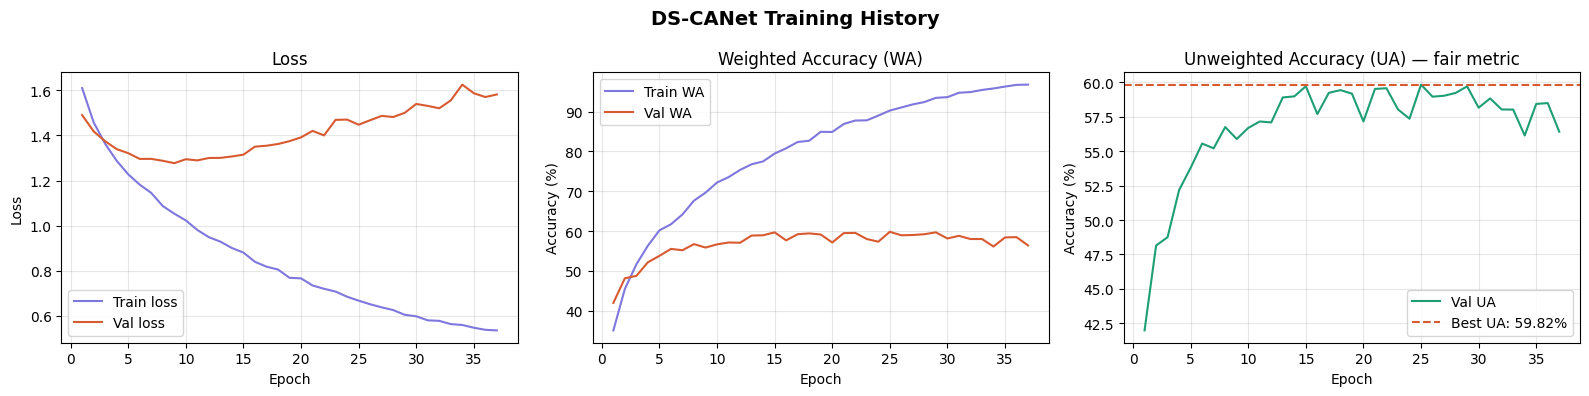

In [18]:
# Plot training history

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("DS-CANet Training History", fontsize=14, fontweight='bold')

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curve
axes[0].plot(epochs_range, history['train_loss'], label='Train loss', color='#7F77DD')
axes[0].plot(epochs_range, history['val_loss'],   label='Val loss',   color='#D85A30')
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Weighted Accuracy
axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train WA', color='#7F77DD')
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val WA',   color='#D85A30')
axes[1].set_title("Weighted Accuracy (WA)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Unweighted Accuracy
axes[2].plot(epochs_range, [u*100 for u in history['val_ua']], color='#1D9E75', label='Val UA')
axes[2].axhline(y=best_val_ua*100, color='#D85A30', linestyle='--', label=f'Best UA: {best_val_ua:.2%}')
axes[2].set_title("Unweighted Accuracy (UA) — fair metric")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy (%)")
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# Final evaluation on held-out test set
#
# RULE: evaluate on the test set ONLY ONCE — at the very end.
# Never use test set results to make training decisions.
# The model was chosen based on val UA, not test UA.

test_loss, test_wa, test_ua, test_preds, test_labels = evaluate(
    model, test_loader, criterion, DEVICE
)

print("=" * 55)
print("         FINAL TEST SET RESULTS")
print("=" * 55)
print(f"  Weighted Accuracy   (WA) : {test_wa:.4f}  ({test_wa:.2%})")
print(f"  Unweighted Accuracy (UA) : {test_ua:.4f}  ({test_ua:.2%})")
print(f"  Test Loss                : {test_loss:.4f}")
print("=" * 55)

# Per-class classification report
target_names = [int_to_label[i] for i in range(NUM_CLASSES)]
print("\nPer-class breakdown:")
print(classification_report(test_labels, test_preds, target_names=target_names, digits=4))

         FINAL TEST SET RESULTS
  Weighted Accuracy   (WA) : 0.5949  (59.49%)
  Unweighted Accuracy (UA) : 0.5948  (59.48%)
  Test Loss                : 1.4052

Per-class breakdown:
              precision    recall  f1-score   support

       angry     0.6818    0.7229    0.7018       249
     disgust     0.5936    0.5242    0.5567       248
        fear     0.5254    0.5847    0.5534       248
       happy     0.5075    0.5422    0.5243       249
     neutral     0.6549    0.6707    0.6627       249
         sad     0.6161    0.5242    0.5664       248

    accuracy                         0.5949      1491
   macro avg     0.5966    0.5948    0.5942      1491
weighted avg     0.5966    0.5949    0.5943      1491



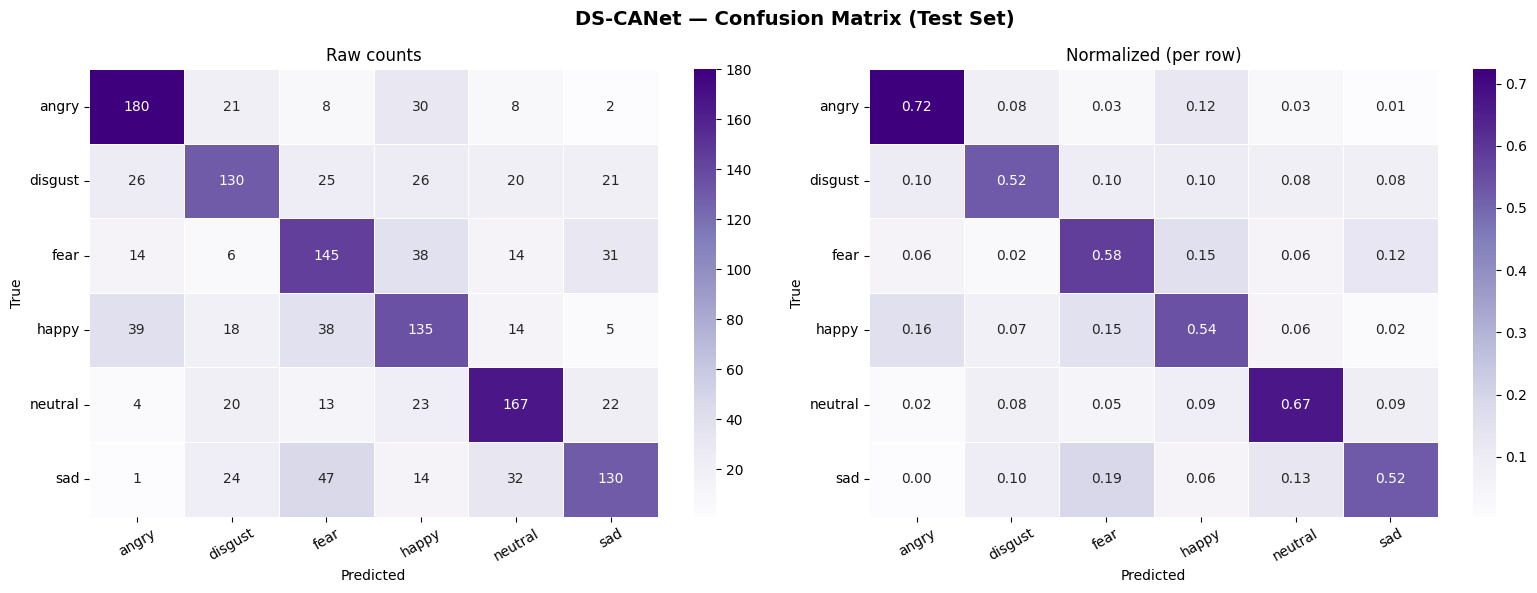

In [20]:
# Confusion matrix
#
# The confusion matrix tells you WHICH emotions get confused with which.
# This is far more informative than a single accuracy number.
# Common confusions in SER: sad↔fear, angry↔disgust.

cm = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)   # normalize per row

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("DS-CANet — Confusion Matrix (Test Set)", fontsize=14, fontweight='bold')

for ax, data, title, fmt in [
    (axes[0], cm,      "Raw counts",          "d"),
    (axes[1], cm_norm, "Normalized (per row)", ".2f")
]:
    sns.heatmap(
        data,
        annot       = True,
        fmt         = fmt,
        cmap        = "Purples",
        xticklabels = target_names,
        yticklabels = target_names,
        ax          = ax,
        linewidths  = 0.5,
        linecolor   = "white"
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Ablation: DS-CANet WITHOUT cross-attention
#
# This is your most important academic result.
# Train the same architecture but replace cross-attention with
# simple concatenation, then compare WA/UA.
# If cross-attention gives +2–4% UA, that IS the contribution.

class DSCANet_NoCrossAttn(nn.Module):
    """Ablation baseline: same architecture but naive fusion (no cross-attention)."""
    def __init__(self, spectral_dim, temporal_dim, d_model, num_heads,
                 num_classes, dropout, lstm_hidden, lstm_layers, temporal_steps):
        super().__init__()
        self.spectral_encoder = SpectralEncoder(spectral_dim, d_model, num_heads, dropout)
        self.temporal_encoder = TemporalEncoder(temporal_dim, d_model, num_heads, dropout,
                                                lstm_hidden, lstm_layers, temporal_steps)
        self.pool_a = EmotionAwarePooling(d_model)
        self.pool_b = EmotionAwarePooling(d_model)
        # Simple concatenation then linear (no cross-attention)
        self.fusion_proj = nn.Linear(d_model * 2, d_model)
        self.norm_fusion  = nn.LayerNorm(d_model)
        self.classifier   = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )

    def forward(self, x_spectral, x_temporal):
        feat_a = self.spectral_encoder(x_spectral)
        feat_b = self.temporal_encoder(x_temporal)
        feat_a = self.pool_a(feat_a)
        feat_b = self.pool_b(feat_b)
        # Naive concatenation (no cross-attention)
        fused  = self.fusion_proj(torch.cat([feat_a, feat_b], dim=-1))
        fused  = self.norm_fusion(fused)
        return self.classifier(fused)


# Train the ablation model with identical hyperparameters
ablation_model = DSCANet_NoCrossAttn(
    spectral_dim=SPECTRAL_DIM, temporal_dim=TEMPORAL_DIM, d_model=128,
    num_heads=4, num_classes=NUM_CLASSES, dropout=0.3,
    lstm_hidden=128, lstm_layers=2, temporal_steps=10
).to(DEVICE)

ablation_optimizer = AdamW(ablation_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
ablation_scheduler = CosineAnnealingLR(ablation_optimizer, T_max=EPOCHS, eta_min=1e-6)

best_ablation_ua = 0.0
best_ablation_wts = copy.deepcopy(ablation_model.state_dict())

print("Training ablation model (no cross-attention)...")
for epoch in tqdm(range(1, EPOCHS + 1)):
    train_one_epoch(ablation_model, train_loader, ablation_optimizer, criterion, DEVICE)
    _, _, val_ua, _, _ = evaluate(ablation_model, val_loader, criterion, DEVICE)
    ablation_scheduler.step()
    if val_ua > best_ablation_ua:
        best_ablation_ua  = val_ua
        best_ablation_wts = copy.deepcopy(ablation_model.state_dict())

ablation_model.load_state_dict(best_ablation_wts)
_, abl_wa, abl_ua, _, _ = evaluate(ablation_model, test_loader, criterion, DEVICE)

# Final comparison
print("\n" + "=" * 55)
print("           ABLATION COMPARISON")
print("=" * 55)
print(f"{'Model':<30} {'WA':>8} {'UA':>8}")
print("-" * 55)
print(f"{'DS-CANet (full)':<30} {test_wa:>8.2%} {test_ua:>8.2%}")
print(f"{'DS-CANet w/o cross-attn':<30} {abl_wa:>8.2%} {abl_ua:>8.2%}")
print("-" * 55)
delta_wa = test_wa - abl_wa
delta_ua = test_ua - abl_ua
print(f"{'Gain from cross-attention':<30} {delta_wa:>+8.2%} {delta_ua:>+8.2%}")
print("=" * 55)

Training ablation model (no cross-attention)...


100%|██████████| 100/100 [03:06<00:00,  1.86s/it]


           ABLATION COMPARISON
Model                                WA       UA
-------------------------------------------------------
DS-CANet (full)                  59.49%   59.48%
DS-CANet w/o cross-attn          58.95%   58.94%
-------------------------------------------------------
Gain from cross-attention        +0.54%   +0.54%


In [22]:
# Save model, config, and results

# Final model
torch.save(model.state_dict(), OUTPUT_DIR / "dscanet_final.pt")

# Config for reproducible loading later
config = {
    "architecture" : "DSCANet",
    "spectral_dim" : SPECTRAL_DIM,
    "temporal_dim" : TEMPORAL_DIM,
    "d_model"      : 128,
    "num_heads"    : 4,
    "num_classes"  : NUM_CLASSES,
    "dropout"      : 0.3,
    "lstm_hidden"  : 128,
    "lstm_layers"  : 2,
    "temporal_steps": 10,
    "label_to_int" : label_to_int,
    "int_to_label" : int_to_label,
    "test_wa"      : round(test_wa, 4),
    "test_ua"      : round(test_ua, 4),
    "ablation_wa"  : round(abl_wa, 4),
    "ablation_ua"  : round(abl_ua, 4),
    "cross_attn_gain_ua": round(delta_ua, 4)
}
with open(OUTPUT_DIR / "model_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<35} ({size:.1f} KB)")

Saved:
  best_model.pt                       (4524.5 KB)
  confusion_matrix.png                (130.6 KB)
  dscanet_final.pt                    (4524.7 KB)
  model_config.json                   (0.6 KB)
  scaler.pkl                          (9.5 KB)
  training_curves.png                 (135.0 KB)
